**Problem Statement:**

You are a Data Scientist in a big firm. You have to develop a deep learning model
to perform sentiment analysis on a dataset of tweets related to various
candidates.


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
import re
import string
import shutil

import nltk
from nltk.corpus import stopwords


**Data Loading and Preprocessing:**

● Load the tweet data from a CSV file.

● Filter out the relevant columns: 'candidate', 'sentiment', and 'text'.

● Preprocess the text data by removing stop words, punctuation, converting to lowercase, and other cleaning steps.


In [38]:
shutil.unpack_archive('/content/NLP_DataSet.zip')
df = pd.read_csv('/content/NLP/twitter_training.csv')

In [39]:
#preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [40]:
df.columns=['slno', 'candidate', 'sentiment', 'text']
# df.head(10)
# df['slno'].value_counts()
# df.info()
df = df[['candidate', 'sentiment', 'text']]

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   candidate  74681 non-null  object
 1   sentiment  74681 non-null  object
 2   text       73995 non-null  object
dtypes: object(3)
memory usage: 1.7+ MB


In [42]:
df = df[~df['text'].isna()]

In [43]:
def clean_text(text:str)->str:
    # print(text)
    text = text.lower()
    text = re.sub(r'http\S+', '', text) #removing url
    text = re.sub(r'@\w+', '', text) # removing mentions
    text = re.sub(r'#', '', text) # remove #
    # print(text)
    # text = re.sub(r'[^\w\s]', '', text) # not word-char or space
    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)
    return text

df['clean_text'] = df['text'].apply(clean_text)


In [44]:
# nltk.download()

In [45]:
# Remove stopwards
sw = set(stopwords.words('english'))

def remove_stopwords(text):
  return ''.join([w for w in text.split() if not w in sw])

df['text'] = df['text'].apply(remove_stopwords)


In [46]:
#encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

y = tf.keras.utils.to_categorical(df['sentiment'])


**Text Vectorization:**

Convert the preprocessed text data into numerical format using tokenization and padding, so that it can be fed into a deep learning model.

In [47]:
#tokenization
vocabulary_size = 10000
maxlen = 50

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=vocabulary_size)#, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
X = tf.keras.preprocessing.sequence.pad_sequences(X, maxlen=maxlen)


In [48]:
#train test split
X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y, test_size=0.2, random_state=42)

**Model Development:**

Develop a deep learning model using TensorFlow and Keras. The model includes an Embedding layer, a SpatialDropout1D layer to prevent overfitting, an LSTM layer for sequence data processing, and a Dense layer for output. It aims to
classify the sentiment of each tweet into one of the three categories.


**Model Training and Evaluation:**

● Train the model on the processed text data, using categorical cross-entropy as the loss function, and accuracy as the evaluation metric.

● Use a validation split to evaluate the model's performance and prevent overfitting.


In [56]:
model = tf.keras.models.Sequential()

#word embedding layer
model.add(
    tf.keras.layers.Embedding(
        input_dim=vocabulary_size, output_dim=128, input_length=maxlen
    )
)

model.add(
    tf.keras.layers.SpatialDropout1D(0.2)
)

model.add(
    tf.keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)
    )

#output layer with softmax
model.add(
    tf.keras.layers.Dense(
        4, activation='softmax'
    )
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [57]:
#compile model
model.compile(
    optimizer='Adam',
    loss=tf.keras.losses.categorical_crossentropy,
    # sparse_categorical_crossentropy #if no one-hot encoding
    metrics=['accuracy']
)

In [55]:
# y_train[0]

array([1., 0., 0., 0.])

In [58]:
#ttain model
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_data=(X_val, y_val)
)

Epoch 1/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 72s 142ms/step - accuracy: 0.5662 - loss: 1.0355 - val_accuracy: 0.6959 - val_loss: 0.7902
Epoch 2/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 65s 140ms/step - accuracy: 0.7377 - loss: 0.6774 - val_accuracy: 0.7461 - val_loss: 0.6699
Epoch 3/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 80s 137ms/step - accuracy: 0.7909 - loss: 0.5506 - val_accuracy: 0.7719 - val_loss: 0.6094
Epoch 4/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.8201 - loss: 0.4781 - val_accuracy: 0.7857 - val_loss: 0.5752
Epoch 5/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 63s 136ms/step - accuracy: 0.8421 - loss: 0.4202 - val_accuracy: 0.7977 - val_loss: 0.5629
Epoch 6/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 61s 133ms/step - accuracy: 0.8593 - loss: 0.3743 - val_accuracy: 0.8057 - val_loss: 0.5487
Epoch 7/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 84s 136ms/step - accuracy: 0.8743 - loss: 0.3337 - val_accuracy: 0.8149 - val_loss: 0.5380
Epoch 8/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - accuracy: 0.8850 - loss: 0

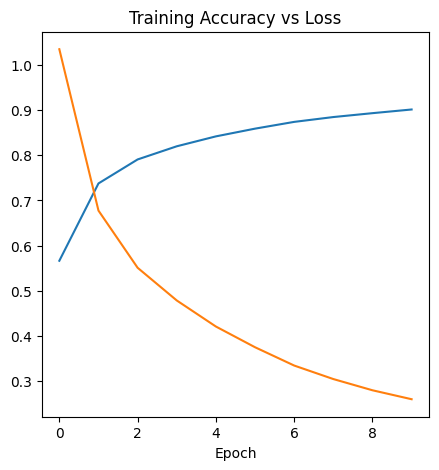

In [79]:
# plot epochs result
plt.figure(figsize=(5, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.title('Training Accuracy vs Loss')
plt.xlabel('Epoch')
plt.show()

In [60]:
#evaluate model
loss, acc = model.evaluate(X_val, y_val)
print(acc)
print(loss)

463/463 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8270 - loss: 0.5507
0.8270153403282166
0.5507364869117737


In [77]:
# prediction -unseen data
def predict_statement(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=maxlen)
    pred = model.predict(padded)
    pred_label_encoded = np.argmax(pred)
    pred_sentiment = le.inverse_transform([pred_label_encoded])[0]
    confidence_level = np.max(pred)
    return pred_sentiment, np.round(confidence_level, 2)


In [78]:
predict_statement('I love India')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


('Positive', np.float32(0.58))